In [1]:
!pip -q install -U \
unsloth \
datasets \
sentence-transformers \
bert-score \
evaluate \
scikit-learn \
pandas \
matplotlib \
tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.4/57.4 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 MB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 596.4/596.4 kB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 101.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 92.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 85.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 676

In [2]:
import os

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import gc
import re
import json
import time
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch

from datasets import load_dataset

# ----------------------------
# Import Unsloth FIRST
# ----------------------------

from unsloth import FastLanguageModel

from unsloth.chat_templates import (
    train_on_responses_only,
)

# ----------------------------
# Remaining imports
# ----------------------------

from trl import SFTTrainer, SFTConfig

from peft import PeftModel

from sentence_transformers import (
    SentenceTransformer,
    util,
)

from bert_score import score as bert_score

from sklearn.metrics import accuracy_score

from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

# ============================================================
# Reproducibility
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

torch.set_float32_matmul_precision("high")

# ============================================================
# Environment
# ============================================================

print("=" * 70)

print("Torch :", torch.__version__)
print("CUDA  :", torch.cuda.is_available())

if torch.cuda.is_available():

    print("GPU   :", torch.cuda.get_device_name(0))
    print("CUDA  :", torch.version.cuda)

    print(
        "Memory:",
        round(
            torch.cuda.get_device_properties(0).total_memory / 1024**3,
            2,
        ),
        "GB",
    )

print("=" * 70)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
Torch : 2.10.0+cu128
CUDA  : True
GPU   : Tesla T4
CUDA  : 12.8
Memory: 14.56 GB


In [3]:
# ============================================================
# Configuration
# ============================================================

# ------------------------------------------------------------
# Model
# ------------------------------------------------------------

BASE_MODEL = "unsloth/Qwen3-8B"

MAX_SEQ_LENGTH = 6144

LOAD_IN_4BIT = True

DTYPE = None

# ------------------------------------------------------------
# Dataset
# ------------------------------------------------------------

DATASET_PATH = "/kaggle/input/datasets/mantriaditya/train-blue/train_blue.jsonl"

TRAIN_SPLIT = 0.80
VAL_SPLIT = 0.10
TEST_SPLIT = 0.10

# ------------------------------------------------------------
# LoRA
# ------------------------------------------------------------

LORA_RANK = 32
LORA_ALPHA = 64
LORA_DROPOUT = 0.05

TARGET_MODULES = [

    "q_proj",
    "k_proj",
    "v_proj",
    "o_proj",

    "gate_proj",
    "up_proj",
    "down_proj",

]

# ------------------------------------------------------------
# Training
# ------------------------------------------------------------

BATCH_SIZE = 1

GRAD_ACCUM = 16

EPOCHS = 3

LEARNING_RATE = 2e-4

WEIGHT_DECAY = 0.01

WARMUP_RATIO = 0.05

LOGGING_STEPS = 10

OUTPUT_DIR = "./outputs"

SAVE_STRATEGY = "epoch"

EVAL_STRATEGY = "epoch"

SAVE_TOTAL_LIMIT = 5

# ------------------------------------------------------------
# Generation
# ------------------------------------------------------------

MAX_NEW_TOKENS = 1024

TEMPERATURE = 0.1

TOP_P = 0.95

DO_SAMPLE = False

# ------------------------------------------------------------
# Misc
# ------------------------------------------------------------

SEED = 42

print("=" * 70)
print("Configuration Loaded")
print("=" * 70)

print(f"Model              : {BASE_MODEL}")
print(f"Context Length     : {MAX_SEQ_LENGTH}")
print(f"Epochs             : {EPOCHS}")
print(f"Batch Size         : {BATCH_SIZE}")
print(f"Gradient Accum     : {GRAD_ACCUM}")
print(f"Learning Rate      : {LEARNING_RATE}")

print("=" * 70)

Configuration Loaded
Model              : unsloth/Qwen3-8B
Context Length     : 6144
Epochs             : 3
Batch Size         : 1
Gradient Accum     : 16
Learning Rate      : 0.0002


In [4]:
# ============================================================
# Load Base Model
# ============================================================

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=BASE_MODEL,
    max_seq_length=MAX_SEQ_LENGTH,
    dtype=DTYPE,
    load_in_4bit=True,
    device_map={"": torch.cuda.current_device()},
)

model.config.use_cache = False

print("=" * 70)
print("Base Model Loaded Successfully")
print("=" * 70)

print(f"Model          : {BASE_MODEL}")
print(f"Tokenizer       : {tokenizer.name_or_path}")
print(f"Vocabulary Size : {tokenizer.vocab_size}")
print(f"Max Context     : {MAX_SEQ_LENGTH}")

print("=" * 70)

==((====))==  Unsloth 2026.7.3: Fast Qwen3 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/399 [00:00<?, ?it/s]

Base Model Loaded Successfully
Model          : unsloth/Qwen3-8B
Tokenizer       : unsloth/qwen3-8b-unsloth-bnb-4bit
Vocabulary Size : 151643
Max Context     : 6144


In [5]:
# ============================================================
# Apply LoRA
# ============================================================

model = FastLanguageModel.get_peft_model(

    model,

    r=LORA_RANK,

    target_modules=TARGET_MODULES,

    lora_alpha=LORA_ALPHA,

    lora_dropout=LORA_DROPOUT,

    bias="none",

    use_gradient_checkpointing="unsloth",

    random_state=SEED,

)

print("=" * 70)
print("LoRA Successfully Applied")
print("=" * 70)

model.print_trainable_parameters()

print("=" * 70)

Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.
Unsloth 2026.7.3 patched 36 layers with 0 QKV layers, 0 O layers and 0 MLP layers.


LoRA Successfully Applied
trainable params: 87,293,952 || all params: 8,278,029,312 || trainable%: 1.0545


In [6]:
# ============================================================
# Load Dataset
# ============================================================

dataset = load_dataset(

    "json",

    data_files=DATASET_PATH,

    split="train",

)

print("=" * 70)
print("Dataset Loaded Successfully")
print("=" * 70)

print(dataset)

print("=" * 70)
print(f"Total Samples : {len(dataset)}")
print("=" * 70)

print("Sample Conversation")
print("=" * 70)

for message in dataset[0]["messages"]:

    print(f"{message['role'].upper()}")

    print("-" * 50)

    print(message["content"][:800])

    print()

Generating train split: 0 examples [00:00, ? examples/s]

Dataset Loaded Successfully
Dataset({
    features: ['scenario_id', 'example_id', 'messages'],
    num_rows: 551
})
Total Samples : 551
Sample Conversation
SYSTEM
--------------------------------------------------
You are a Blue Team cybersecurity analyst specializing in architectural security assessments of enterprise software systems.

Your objective is to identify the single most effective defensive mitigation that addresses the root cause of the observed attack using the provided business context, architecture, workflow, trust boundaries, and source code.

Perform a structured architectural analysis before reaching a conclusion.

During your analysis:

• Identify the canonical security boundary of the application.
• Follow the end-to-end business workflow.
• Track how security-critical information is transformed between components.
• Distinguish architectural weaknesses from implementation details.
• Eliminate competing defensive hypotheses before selecting the final defense.
• Bas

Computing Dataset Statistics...


  0%|          | 0/551 [00:00<?, ?it/s]


Total Samples        : 551
Average Tokens       : 6989.43
Median Tokens        : 6537.00
95th Percentile      : 13306.50
99th Percentile      : 17829.50
Maximum Tokens       : 19323
Minimum Tokens       : 969


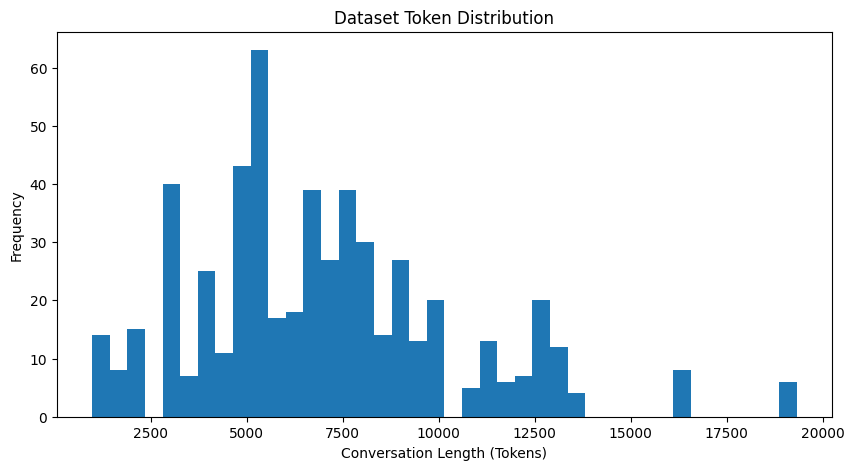

In [7]:
# ============================================================
# Dataset Statistics
# ============================================================

def count_tokens(example):
    text = ""

    for message in example["messages"]:
        text += message["content"] + "\n"

    return len(tokenizer(text, add_special_tokens=False)["input_ids"])


print("=" * 70)
print("Computing Dataset Statistics...")
print("=" * 70)

token_lengths = []

for sample in tqdm(dataset):

    token_lengths.append(
        count_tokens(sample)
    )

token_lengths = np.array(token_lengths)

print()

print("=" * 70)

print(f"Total Samples        : {len(dataset)}")
print(f"Average Tokens       : {np.mean(token_lengths):.2f}")
print(f"Median Tokens        : {np.median(token_lengths):.2f}")
print(f"95th Percentile      : {np.percentile(token_lengths,95):.2f}")
print(f"99th Percentile      : {np.percentile(token_lengths,99):.2f}")
print(f"Maximum Tokens       : {np.max(token_lengths)}")
print(f"Minimum Tokens       : {np.min(token_lengths)}")

print("=" * 70)

plt.figure(figsize=(10,5))

plt.hist(
    token_lengths,
    bins=40,
)

plt.xlabel("Conversation Length (Tokens)")
plt.ylabel("Frequency")
plt.title("Dataset Token Distribution")

plt.show()

In [8]:
# ============================================================
# Train / Validation / Test Split
# ============================================================

dataset = dataset.shuffle(seed=SEED)

train_test = dataset.train_test_split(
    test_size=0.20,
    seed=SEED,
)

train_dataset = train_test["train"]

remaining_dataset = train_test["test"]

validation_test = remaining_dataset.train_test_split(
    test_size=0.50,
    seed=SEED,
)

validation_dataset = validation_test["train"]

test_dataset = validation_test["test"]

print("=" * 70)

print(f"Training Samples   : {len(train_dataset)}")
print(f"Validation Samples : {len(validation_dataset)}")
print(f"Test Samples       : {len(test_dataset)}")

print("=" * 70)

Training Samples   : 440
Validation Samples : 55
Test Samples       : 56


In [9]:
# ============================================================
# Apply Chat Template
# ============================================================

def formatting_prompts_func(examples):

    conversations = examples["messages"]

    texts = [

        tokenizer.apply_chat_template(
            conversation,
            tokenize=False,
            add_generation_prompt=False,
        )

        for conversation in conversations

    ]

    return {

        "text": texts,

    }


train_dataset = train_dataset.map(
    formatting_prompts_func,
    batched=True,
)

validation_dataset = validation_dataset.map(
    formatting_prompts_func,
    batched=True,
)

test_dataset = test_dataset.map(
    formatting_prompts_func,
    batched=True,
)

print("=" * 70)
print("Chat Template Applied")
print("=" * 70)

print(train_dataset[0]["text"])

Map:   0%|          | 0/440 [00:00<?, ? examples/s]

Map:   0%|          | 0/55 [00:00<?, ? examples/s]

Map:   0%|          | 0/56 [00:00<?, ? examples/s]

Chat Template Applied
<|im_start|>system
You are a Blue Team cybersecurity analyst specializing in architectural security assessments of enterprise software systems.

Your objective is to identify the single most effective defensive mitigation that addresses the root cause of the observed attack using the provided business context, architecture, workflow, trust boundaries, and source code.

Perform a structured architectural analysis before reaching a conclusion.

During your analysis:

• Identify the canonical security boundary of the application.
• Follow the end-to-end business workflow.
• Track how security-critical information is transformed between components.
• Distinguish architectural weaknesses from implementation details.
• Eliminate competing defensive hypotheses before selecting the final defense.
• Base every conclusion only on the supplied information.

Do not assume undocumented behavior.

Do not invent vulnerabilities, mitigations, or architectural details that are not

In [10]:
# ============================================================
# Trainer Configuration
# ============================================================

training_args = SFTConfig(

    output_dir=OUTPUT_DIR,

    max_length=MAX_SEQ_LENGTH,

    dataset_text_field="text",

    packing=False,

    per_device_train_batch_size=BATCH_SIZE,

    per_device_eval_batch_size=1,

    gradient_accumulation_steps=GRAD_ACCUM,

    learning_rate=LEARNING_RATE,

    num_train_epochs=EPOCHS,

    warmup_ratio=WARMUP_RATIO,

    weight_decay=WEIGHT_DECAY,

    logging_steps=LOGGING_STEPS,

    logging_strategy="steps",

    eval_strategy="epoch",

    save_strategy="epoch",

    save_total_limit=SAVE_TOTAL_LIMIT,

    load_best_model_at_end=True,

    metric_for_best_model="eval_loss",

    greater_is_better=False,

    bf16=torch.cuda.is_bf16_supported(),

    fp16=not torch.cuda.is_bf16_supported(),

    optim="adamw_8bit",

    lr_scheduler_type="cosine",

    report_to="none",

    seed=SEED,
)

trainer = SFTTrainer(

    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=validation_dataset,

    processing_class=tokenizer,

)

trainer = train_on_responses_only(

    trainer,

    instruction_part="<|im_start|>user\n",

    response_part="<|im_start|>assistant\n",

)

print("=" * 70)
print("Trainer Ready")
print("=" * 70)

print("Training Samples   :", len(train_dataset))
print("Validation Samples :", len(validation_dataset))
print("Test Samples       :", len(test_dataset))

print("=" * 70)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Unsloth: Tokenizing ["text"] (num_proc=8):   0%|          | 0/440 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=8):   0%|          | 0/55 [00:00<?, ? examples/s]

🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


Map:   0%|          | 0/440 [00:00<?, ? examples/s]

Filter:   0%|          | 0/440 [00:00<?, ? examples/s]

Unsloth: Removed 225 out of 440 samples from train_dataset where all labels were -100 (no response marker found, usually truncation). This prevents NaN loss during training.


Map:   0%|          | 0/55 [00:00<?, ? examples/s]

Filter:   0%|          | 0/55 [00:00<?, ? examples/s]

Unsloth: Removed 26 out of 55 samples from eval_dataset where all labels were -100 (no response marker found, usually truncation). This prevents NaN loss during training.
Trainer Ready
Training Samples   : 440
Validation Samples : 55
Test Samples       : 56


In [11]:
print(trainer.args.max_length)

6144


In [12]:
# ============================================================
# Train Model
# ============================================================

print("=" * 70)
print("Starting Training")
print("=" * 70)

start_time = time.time()

trainer_stats = trainer.train()

training_time = time.time() - start_time

print("=" * 70)
print("Training Complete")
print("=" * 70)

print(f"Training Time : {training_time/60:.2f} minutes")
print(f"Training Loss : {trainer_stats.training_loss:.6f}")

print("=" * 70)

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


Starting Training


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 215 | Num Epochs = 3 | Total steps = 42
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 16
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 16 x 1) = 16
 "-____-"     Trainable parameters = 87,293,952 of 8,278,029,312 (1.05% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Epoch,Training Loss,Validation Loss
1,2.158405,1.456660
2,1.477392,1.290449
3,1.122707,1.267729


Unsloth: Restored added_tokens_decoder metadata in ./outputs/checkpoint-14/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in ./outputs/checkpoint-28/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in ./outputs/checkpoint-42/tokenizer_config.json.


Training Complete
Training Time : 166.00 minutes
Training Loss : 1.479033


In [13]:
# ============================================================
# Save Best Adapter
# ============================================================

BEST_MODEL_DIR = os.path.join(OUTPUT_DIR, "best_adapter")

trainer.save_model(BEST_MODEL_DIR)
tokenizer.save_pretrained(BEST_MODEL_DIR)

print("=" * 70)
print("Best Adapter Saved")
print("=" * 70)

print(BEST_MODEL_DIR)

Unsloth: Restored added_tokens_decoder metadata in ./outputs/best_adapter/tokenizer_config.json.


Best Adapter Saved
./outputs/best_adapter


In [14]:
# ============================================================
# Inference Function
# ============================================================

FastLanguageModel.for_inference(model)
model.eval()

def generate_response(messages):

    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
    ).to(model.device)

    with torch.inference_mode():

        outputs = model.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            do_sample=DO_SAMPLE,
            temperature=None if not DO_SAMPLE else TEMPERATURE,
            top_p=None if not DO_SAMPLE else TOP_P,
            use_cache=True,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    prediction = tokenizer.decode(
        outputs[0][inputs.input_ids.shape[1]:],
        skip_special_tokens=True,
    )

    return prediction.strip()


print("=" * 70)
print("Inference Function Ready")
print("=" * 70)

Inference Function Ready


In [15]:
# ============================================================
# Generate Validation Predictions
# ============================================================

validation_predictions = []

print("=" * 70)
print("Generating Validation Predictions")
print("=" * 70)

for sample in tqdm(validation_dataset):

    messages = sample["messages"][:-1]

    ground_truth = sample["messages"][-1]["content"]

    prediction = generate_response(messages)

    validation_predictions.append({

        "messages": messages,
        "ground_truth": ground_truth,
        "prediction": prediction,

    })

print("=" * 70)
print(f"Generated {len(validation_predictions)} Validation Predictions")
print("=" * 70)

# ============================================================
# Display One Validation Example
# ============================================================

example = validation_predictions[0]

print("\n" + "=" * 80)
print("VALIDATION SAMPLE")
print("=" * 80)

print("\nINPUT MESSAGES")

for message in example["messages"]:

    print(f"\n[{message['role'].upper()}]")
    print(message["content"][:1500])

print("\n" + "=" * 80)
print("GROUND TRUTH")
print("=" * 80)

print(example["ground_truth"])

print("\n" + "=" * 80)
print("PREDICTION (Trained Adapter)")
print("=" * 80)

print(example["prediction"])

print("=" * 80)

Generating Validation Predictions


  0%|          | 0/55 [00:00<?, ?it/s]

Both `max_new_tokens` (=1024) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=1024) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=1024) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=1024) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_

Generated 55 Validation Predictions

VALIDATION SAMPLE

INPUT MESSAGES

[SYSTEM]
You are a Blue Team cybersecurity analyst specializing in architectural security assessments of enterprise software systems.

Your objective is to identify the single most effective defensive mitigation that addresses the root cause of the observed attack using the provided business context, architecture, workflow, trust boundaries, and source code.

Perform a structured architectural analysis before reaching a conclusion.

During your analysis:

• Identify the canonical security boundary of the application.
• Follow the end-to-end business workflow.
• Track how security-critical information is transformed between components.
• Distinguish architectural weaknesses from implementation details.
• Eliminate competing defensive hypotheses before selecting the final defense.
• Base every conclusion only on the supplied information.

Do not assume undocumented behavior.

Do not invent vulnerabilities, mitigation

In [16]:
# ============================================================
# Evaluation Helper Functions
# ============================================================

def clean_prediction(text):
    """
    Removes optional thinking blocks generated by some models.
    """

    text = re.sub(
        r"<think>.*?</think>",
        "",
        text,
        flags=re.DOTALL | re.IGNORECASE,
    )

    return text.strip()


def extract_defense(text):

    text = clean_prediction(text)

    match = re.search(
        r"Defense:\s*(.*?)(?=Reasoning:|$)",
        text,
        flags=re.DOTALL | re.IGNORECASE,
    )

    if match:
        return match.group(1).strip()

    return ""


def extract_reasoning(text):

    text = clean_prediction(text)

    match = re.search(
        r"Reasoning:\s*(.*?)(?=Defense:|$)",
        text,
        flags=re.DOTALL | re.IGNORECASE,
    )

    if match:
        return match.group(1).strip()

    return ""


def normalize(text):

    text = text.lower().strip()

    text = re.sub(
        r"\s+",
        " ",
        text,
    )

    return text


def structure_correct(text):
    """
    Checks whether the required sections exist.
    """

    text = clean_prediction(text)

    has_defense = re.search(
        r"Defense:",
        text,
        re.IGNORECASE,
    )

    has_reasoning = re.search(
        r"Reasoning:",
        text,
        re.IGNORECASE,
    )

    return bool(has_defense and has_reasoning)


print("=" * 70)
print("Evaluation Helper Functions Ready")
print("=" * 70)

Evaluation Helper Functions Ready


In [17]:
# ============================================================
# Validation Metrics
# ============================================================

ground_truth_defenses = []
predicted_defenses = []

ground_truth_reasoning = []
predicted_reasoning = []

structure_scores = []

for sample in validation_predictions:

    gt = sample["ground_truth"]
    pred = sample["prediction"]

    gt_defense = normalize(
        extract_defense(gt)
    )

    pred_defense = normalize(
        extract_defense(pred)
    )

    gt_reasoning = extract_reasoning(gt)

    pred_reasoning = extract_reasoning(pred)

    ground_truth_defenses.append(gt_defense)
    predicted_defenses.append(pred_defense)

    ground_truth_reasoning.append(gt_reasoning)
    predicted_reasoning.append(pred_reasoning)

    structure_scores.append(
        int(
            structure_correct(pred)
        )
    )

defense_accuracy = accuracy_score(
    ground_truth_defenses,
    predicted_defenses,
)

P, R, F1 = bert_score(
    predicted_reasoning,
    ground_truth_reasoning,
    lang="en",
    verbose=False,
)

bert_f1 = float(F1.mean())

structure_accuracy = float(
    np.mean(structure_scores)
)

print("=" * 70)
print("Validation Metrics")
print("=" * 70)

print(f"Defense Accuracy   : {defense_accuracy:.4f}")
print(f"BERTScore F1       : {bert_f1:.4f}")
print(f"Structure Accuracy : {structure_accuracy:.4f}")

print("=" * 70)

# ============================================================
# Defense Prediction Summary
# ============================================================

correct = sum(
    gt == pred
    for gt, pred in zip(
        ground_truth_defenses,
        predicted_defenses,
    )
)

print(
    f"Correct Defense Predictions : {correct}/{len(ground_truth_defenses)}"
)

incorrect = len(ground_truth_defenses) - correct

print(
    f"Incorrect Predictions       : {incorrect}"
)

# ============================================================
# Show First Incorrect Prediction (if any)
# ============================================================

if incorrect > 0:

    print("\n")
    print("=" * 80)
    print("FIRST INCORRECT VALIDATION PREDICTION")
    print("=" * 80)

    for i in range(len(validation_predictions)):

        if ground_truth_defenses[i] != predicted_defenses[i]:

            print("Ground Truth Defense")
            print("--------------------")
            print(ground_truth_defenses[i])

            print()

            print("Predicted Defense")
            print("-----------------")
            print(predicted_defenses[i])

            print()

            print("=" * 80)
            print("GROUND TRUTH")
            print("=" * 80)

            print(validation_predictions[i]["ground_truth"])

            print()

            print("=" * 80)
            print("PREDICTION")
            print("=" * 80)

            print(validation_predictions[i]["prediction"])

            break

print("=" * 70)

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Validation Metrics
Defense Accuracy   : 0.1455
BERTScore F1       : 0.8564
Structure Accuracy : 1.0000
Correct Defense Predictions : 8/55
Incorrect Predictions       : 47


FIRST INCORRECT VALIDATION PREDICTION
Ground Truth Defense
--------------------
diagnostic_bundle_authorization_and_data_minimization

Predicted Defense
-----------------
field_level_redaction

GROUND TRUTH
Defense: diagnostic_bundle_authorization_and_data_minimization

Reasoning:
Audit logging already exists and records bundle activity, but logging does not prevent disclosure. The underlying issue is that diagnostic exports bypass both authorization constraints and data minimization controls. Remediation requires enforcing customer-scoped access decisions and limiting bundle contents to approved diagnostic fields. Security controls used in standard exports should be consistently applied to diagnostic workflows where appropriate.

PREDICTION
<think>

</think>

Defense: field_level_redaction

Reasoning:
1. Diagnostic

In [18]:
# ============================================================
# Generate Test Predictions
# ============================================================

test_predictions = []

print("=" * 70)
print("Generating Test Predictions")
print("=" * 70)

for sample in tqdm(test_dataset):

    messages = sample["messages"][:-1]

    ground_truth = sample["messages"][-1]["content"]

    prediction = generate_response(messages)

    test_predictions.append({

        "messages": messages,
        "ground_truth": ground_truth,
        "prediction": prediction,

    })

print("=" * 70)
print(f"Generated {len(test_predictions)} Test Predictions")
print("=" * 70)

# ============================================================
# Display One Test Example
# ============================================================

example = test_predictions[0]

print("\n" + "=" * 80)
print("TEST SAMPLE")
print("=" * 80)

print("\nINPUT MESSAGES")

for message in example["messages"]:

    print(f"\n[{message['role'].upper()}]")
    print(message["content"][:1500])

print("\n" + "=" * 80)
print("GROUND TRUTH")
print("=" * 80)

print(example["ground_truth"])

print("\n" + "=" * 80)
print("PREDICTION (Blue Adapter)")
print("=" * 80)

print(example["prediction"])

print("=" * 80)

Generating Test Predictions


  0%|          | 0/56 [00:00<?, ?it/s]

Both `max_new_tokens` (=1024) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=1024) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=1024) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=1024) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_

Generated 56 Test Predictions

TEST SAMPLE

INPUT MESSAGES

[SYSTEM]
You are a Blue Team cybersecurity analyst specializing in architectural security assessments of enterprise software systems.

Your objective is to identify the single most effective defensive mitigation that addresses the root cause of the observed attack using the provided business context, architecture, workflow, trust boundaries, and source code.

Perform a structured architectural analysis before reaching a conclusion.

During your analysis:

• Identify the canonical security boundary of the application.
• Follow the end-to-end business workflow.
• Track how security-critical information is transformed between components.
• Distinguish architectural weaknesses from implementation details.
• Eliminate competing defensive hypotheses before selecting the final defense.
• Base every conclusion only on the supplied information.

Do not assume undocumented behavior.

Do not invent vulnerabilities, mitigations, or archit

In [19]:
# ============================================================
# Test Metrics
# ============================================================

ground_truth_defenses = []
predicted_defenses = []

ground_truth_reasoning = []
predicted_reasoning = []

structure_scores = []

for sample in test_predictions:

    gt = sample["ground_truth"]
    pred = sample["prediction"]

    gt_defense = normalize(
        extract_defense(gt)
    )

    pred_defense = normalize(
        extract_defense(pred)
    )

    gt_reasoning = extract_reasoning(gt)

    pred_reasoning = extract_reasoning(pred)

    ground_truth_defenses.append(gt_defense)
    predicted_defenses.append(pred_defense)

    ground_truth_reasoning.append(gt_reasoning)
    predicted_reasoning.append(pred_reasoning)

    structure_scores.append(
        int(
            structure_correct(pred)
        )
    )

test_defense_accuracy = accuracy_score(
    ground_truth_defenses,
    predicted_defenses,
)

P, R, F1 = bert_score(
    predicted_reasoning,
    ground_truth_reasoning,
    lang="en",
    verbose=False,
)

test_bert_f1 = float(F1.mean())

test_structure_accuracy = float(
    np.mean(structure_scores)
)

print("=" * 70)
print("Test Metrics")
print("=" * 70)

print(f"Defense Accuracy   : {test_defense_accuracy:.4f}")
print(f"BERTScore F1       : {test_bert_f1:.4f}")
print(f"Structure Accuracy : {test_structure_accuracy:.4f}")

print("=" * 70)

# ============================================================
# Defense Prediction Summary
# ============================================================

correct = sum(
    gt == pred
    for gt, pred in zip(
        ground_truth_defenses,
        predicted_defenses,
    )
)

print(
    f"Correct Defense Predictions : {correct}/{len(ground_truth_defenses)}"
)

incorrect = len(ground_truth_defenses) - correct

print(
    f"Incorrect Predictions       : {incorrect}"
)

# ============================================================
# Show First Incorrect Prediction (if any)
# ============================================================

if incorrect > 0:

    print("\n")
    print("=" * 80)
    print("FIRST INCORRECT TEST PREDICTION")
    print("=" * 80)

    for i in range(len(test_predictions)):

        if ground_truth_defenses[i] != predicted_defenses[i]:

            print("Ground Truth Defense")
            print("--------------------")
            print(ground_truth_defenses[i])

            print()

            print("Predicted Defense")
            print("-----------------")
            print(predicted_defenses[i])

            print()

            print("=" * 80)
            print("GROUND TRUTH")
            print("=" * 80)

            print(test_predictions[i]["ground_truth"])

            print()

            print("=" * 80)
            print("PREDICTION")
            print("=" * 80)

            print(test_predictions[i]["prediction"])

            break

# ============================================================
# Save Results
# ============================================================

validation_df = pd.DataFrame(validation_predictions)
test_df = pd.DataFrame(test_predictions)

validation_csv = os.path.join(
    OUTPUT_DIR,
    "validation_predictions.csv",
)

test_csv = os.path.join(
    OUTPUT_DIR,
    "test_predictions.csv",
)

metrics_json = os.path.join(
    OUTPUT_DIR,
    "metrics.json",
)

validation_df.to_csv(
    validation_csv,
    index=False,
)

test_df.to_csv(
    test_csv,
    index=False,
)

metrics = {

    "training_loss": float(trainer_stats.training_loss),

    "validation": {

        "defense_accuracy": float(defense_accuracy),
        "bert_f1": float(bert_f1),
        "structure_accuracy": float(structure_accuracy),

    },

    "test": {

        "defense_accuracy": float(test_defense_accuracy),
        "bert_f1": float(test_bert_f1),
        "structure_accuracy": float(test_structure_accuracy),

    },

}

with open(metrics_json, "w") as f:

    json.dump(
        metrics,
        f,
        indent=4,
    )

print()
print("=" * 70)
print("Training Pipeline Complete")
print("=" * 70)

print(f"Training Loss          : {trainer_stats.training_loss:.4f}")

print()

print("Validation")
print("-" * 70)
print(f"Defense Accuracy       : {defense_accuracy:.4f}")
print(f"BERTScore F1           : {bert_f1:.4f}")
print(f"Structure Accuracy     : {structure_accuracy:.4f}")

print()

print("Test")
print("-" * 70)
print(f"Defense Accuracy       : {test_defense_accuracy:.4f}")
print(f"BERTScore F1           : {test_bert_f1:.4f}")
print(f"Structure Accuracy     : {test_structure_accuracy:.4f}")

print()

print("Saved Files")
print("-" * 70)
print(BEST_MODEL_DIR)
print(validation_csv)
print(test_csv)
print(metrics_json)

print("=" * 70)

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Test Metrics
Defense Accuracy   : 0.1071
BERTScore F1       : 0.8552
Structure Accuracy : 1.0000
Correct Defense Predictions : 6/56
Incorrect Predictions       : 50


FIRST INCORRECT TEST PREDICTION
Ground Truth Defense
--------------------
optimized_bundle_provenance_validation

Predicted Defense
-----------------
artifact_provenance_validation

GROUND TRUTH
Defense: optimized_bundle_provenance_validation

Reasoning:

1. The security invariant that must hold is: every optimized application bundle accepted for publication must be cryptographically bound to an approved application build. Approval should only transfer from the approved build to an optimized bundle after artifact lineage has been verified.

2. ReviewLedger.scala records valid approvals and ApprovedBuildStore.php stores approved application artifacts — these components are correct.

3. BundleComposer.zig correctly generates optimization metadata and BundleManifest.lua preserves approved and optimized artifact digests — the